In [10]:
import torch
import torchaudio
from transformers import AutoFeatureExtractor, Wav2Vec2Model
import utils
import random
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the model and feature extractor
# Wav2Vec 2.0 provides 1D frame-level attention maps without context limits
model_name = "facebook/wav2vec2-base-960h"
feature_extractor = AutoFeatureExtractor.from_pretrained(model_name)
model = Wav2Vec2Model.from_pretrained(
    model_name,
    attn_implementation="eager"  # Forces explicit output of full attention matrices
)
model.eval()

# 2. Define audio file paths
audio_paths = [
    "../music-clips/classical_8.wav",
    "../music-clips/classical_1.wav",
    "../music-clips/classical_2.wav",
    "../music-clips/classical_6.wav",
    "../music-clips/electronic_1.wav",
    "../music-clips/electronic_10.wav",
    "../music-clips/electronic_14.wav",
    "../music-clips/electronic_3.wav",
]

# Helper function mirroring your bulk loader (resamples to 16kHz & converts to mono)
def load_process_bulk_audio(paths, feature_extractor):
    inputs_dict = {}
    for path in paths:
        waveform, sr = torchaudio.load(path)
        
        # Resample to 16,000 Hz if necessary
        if sr != 16000:
            resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=16000)
            waveform = resampler(waveform)
            
        # Convert stereo to mono by averaging channels
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)
            
        waveform_np = waveform.squeeze().numpy()
        
        # Extract features for Wav2Vec2
        inputs = feature_extractor(
            waveform_np, 
            sampling_rate=16000, 
            return_tensors="pt"
        )
        inputs_dict[path] = inputs
    return inputs_dict

inputs_dict = load_process_bulk_audio(audio_paths, feature_extractor)

# 3. Extract attention weights per audio file
attentions_dict = {}

with torch.no_grad():
    for path, inputs in inputs_dict.items():
        input_values = inputs.input_values
        
        # Forward pass returning full multi-layer self-attention maps
        outputs = model(input_values, output_attentions=True)
        
        # outputs.attentions is a tuple of (num_layers,) tensors,
        # each with shape: (batch_size, num_heads, sequence_length, sequence_length)
        # Stack into a single tensor of shape: [num_layers, num_heads, seq_len, seq_len]
        attentions_tensor = torch.stack(outputs.attentions).squeeze(1)
        
        attentions_dict[path] = attentions_tensor

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:
mad_dict = {}
for path, attn in attentions_dict.items():
    seq_length = attn.shape[-1]
    print(path, seq_length)
    mean_distances_seconds = utils.compute_mad_by_layer(attn, seq_length)
    mad_dict[path] = mean_distances_seconds

../music-clips/classical_8.wav 3001
../music-clips/classical_1.wav 3001
../music-clips/classical_2.wav 3001
../music-clips/classical_6.wav 3001
../music-clips/electronic_1.wav 2999
../music-clips/electronic_10.wav 2999
../music-clips/electronic_14.wav 2999
../music-clips/electronic_3.wav 2999


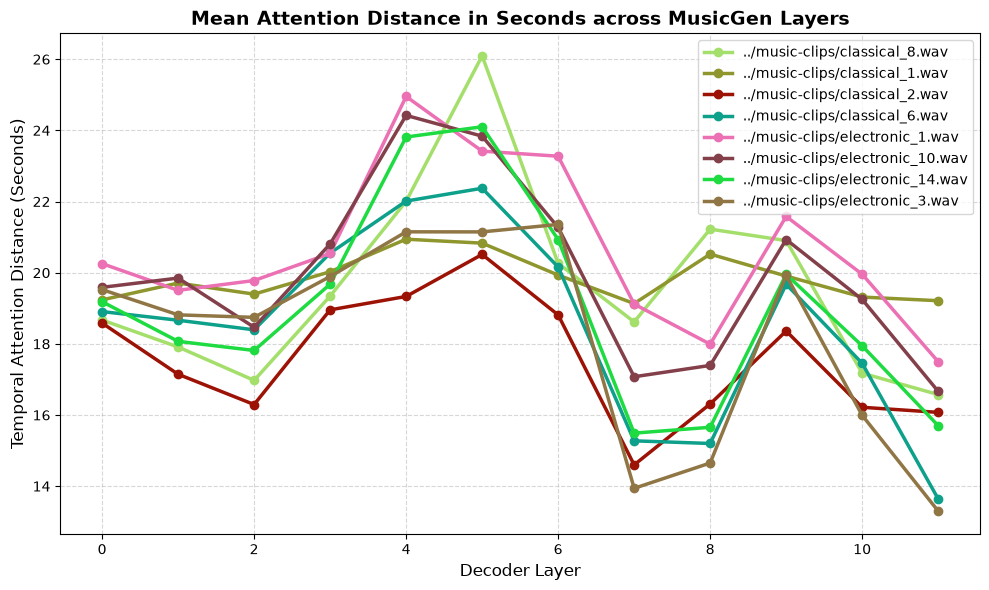

In [12]:
plt.figure(figsize=(10, 6))

for path, mads in mad_dict.items():
    random_hex = f"#{random.randint(0, 0xFFFFFF):06x}"
    num_layers = len(attentions_dict.get(path))
    layer_averages_sec = np.mean(mads, axis=1)
    plt.plot(range(num_layers), layer_averages_sec, color=random_hex, linewidth=2.5, marker='o', label=path)

plt.title("Mean Attention Distance in Seconds across MusicGen Layers", fontsize=14, fontweight='bold')
plt.xlabel("Decoder Layer", fontsize=12)
plt.ylabel("Temporal Attention Distance (Seconds)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()